## 0. Libraries imporation



In [ ]:
# install libs
!pip install -q gensim
!pip install -q transformers
!pip install -q datasets
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import random
import time

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist

# spaCy
import spacy

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

# gensim for word2vec
from gensim.models import Word2Vec




The main Python libraries used across the entire NLP pipeline were pandas, numpy, matplotlib, seaborn,nltk and spaCy,scikit-learn, and genism was omported.

In [ ]:
# nicer pandas + plots
from IPython.display import display

# silence warnings (cleaner output)
import warnings
warnings.filterwarnings('ignore')

# fix seeds everywhere for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# global plot style - applied to all plots in the notebook
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.titleweight']= 'bold'
plt.rcParams['axes.labelsize']  = 11
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

# pandas display - show enough columns
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

In [ ]:
# nltk downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

This section downloads the necessary NLTK tools for text pre-processing such as stopword removal, text tokenisation and lemmatisation. This will allow the NLP pipeline to be text normalised accurately with the help of these resources.

In [ ]:
# load spacy
nlp = spacy.load("en_core_web_sm")
print("spaCy loaded:", nlp.meta['name'], nlp.meta['version'])

spaCy loaded: core_web_sm 3.8.0


In this section, we will install a small version of the English language model (en_core_web_sm) – it is available in Colab's spaCy library. It has different features like tokenization, part of speech tagging and named entity recognition (NER) that are crucial for text preprocessing and analysis. The model can be downloaded if it is not already installed by using !python -m spacy download en_core_web_sm. This model is loaded for high performance and high accuracy of language features to use in the NLP pipeline for further application.

## 1. Load the Banking77 dataset



In [ ]:
# load data
train_df = pd.read_csv('/content/train.csv')
test_df  = pd.read_csv('/content/test.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())

Train shape: (10003, 2)
Test shape : (3080, 2)


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


This dataset is loaded into a pandas DataFrame, and stored in train_df for the training set and test_df for the test set.The sizes of the two DataFrames are reported to ensure the data is correct and a preview of the training data is shown to analyse its structure.

In [ ]:
# distribution of intents
intent_counts = train_df['category'].value_counts()
print("Number of unique intents:", len(intent_counts))

print("\nTop 5 intents:")
display(intent_counts.head().to_frame('count'))

print("Bottom 5 intents:")
display(intent_counts.tail().to_frame('count'))

Number of unique intents: 77

Top 5 intents:


,count
category,
card_payment_fee_charged,187
direct_debit_payment_not_recognised,182
balance_not_updated_after_cheque_or_cash_deposit,181
wrong_amount_of_cash_received,180
cash_withdrawal_charge,177


Bottom 5 intents:


,count
category,
lost_or_stolen_card,82
card_swallowed,61
card_acceptance,59
virtual_card_not_working,41
contactless_not_working,35



In the training set, the intent categories are observed to determine their relative occurrences. There are a total of 77 different intents. The highest five intents (177-187), including card_payment_fee_charged and direct_debit_payment_not_recognised, are the most common intents, and the lowest five (35-61), including contactless_not_working and virtual_card_not_working, are the least common intents.


In [ ]:
# Example of a few utterances
sample = train_df.head(5)[['category', 'text']].copy()
sample.columns = ['Intent', 'Utterance']
display(sample)

,Intent,Utterance
0,card_arrival,I am still waiting on my card?
1,card_arrival,What can I do if my card still hasn't arrived ...
2,card_arrival,I have been waiting over a week. Is the card s...
3,card_arrival,Can I track my card while it is in the process...
4,card_arrival,"How do I know if I will get my card, or if it ..."


This step displays some example customer utterances from the Banking77 dataset and provides their intent labels. Examples show the way in which queries relating to a particular intent (e.g., card_arrival) are clustered.

## Task 1 - Preprocessing & Exploratory Analysis


### 1.1 NLTK preprocessing


The text data was processed using a preprocessing pipeline implemented with NLTK library to prepare the data for natural language processing tasks.

All the text is first converted to lowercase to keep all the tokens consistent. It is then tokenized using word_tokenize.
Using the predefined list of stopwords in English, provided by NLTK, the stopwords are removed to filter non-informative words. Furthermore, punctuation tokens and non-alphabetic tokens are dropped and only meaningful words are kept.

Finally, WordNetLemmatizer is used for lemmatization which helps to convert words to their base form and enhance lexical normalization.

For instance, the input sentence ‘I am still waiting on my card?’ is converted into: ['still', 'waiting', 'card']

This result shows that the preprocessing effectively removes irrelevant elements while preserving the essential meaning of the sentence, making the data more suitable for further analysis or machine learning models.


In [ ]:
# stopwords list
stop_words = set(stopwords.words('english'))

# wordnet lemmatizer
wnl = WordNetLemmatizer()

def preprocess_nltk(text):
    # lower + tokenize
    tokens = word_tokenize(text.lower())
    # remove punctuation and stopwords
    tokens = [t for t in tokens if t not in string.punctuation and t not in stop_words]
    # remove tokens that are not alphabetic
    tokens = [t for t in tokens if t.isalpha()]
    # lemmatize
    tokens = [wnl.lemmatize(t) for t in tokens]
    return tokens

# quick test
sample_text = train_df.iloc[0]['text']
print("Original :", sample_text)
print("NLTK tokens:", preprocess_nltk(sample_text))

Original : I am still waiting on my card?
NLTK tokens: ['still', 'waiting', 'card']


The preprocessing function has been applied to the entire training data set by applying it to the text column of the data set using the apply() method. The cleaned and lemmatised tokens were stored in a new column called tokens_nltk.
For each request from customers, a list of informative tokens was generated, with each being a distinct part of the conversation. For instance: [still, waiting, card] became I am still waiting on my card?


In [ ]:
# apply on the whole training set
train_df['tokens_nltk'] = train_df['text'].apply(preprocess_nltk)
display(train_df[['text', 'tokens_nltk']].head())

,text,tokens_nltk
0,I am still waiting on my card?,"[still, waiting, card]"
1,What can I do if my card still hasn't arrived ...,"[card, still, arrived, week]"
2,I have been waiting over a week. Is the card s...,"[waiting, week, card, still, coming]"
3,Can I track my card while it is in the process...,"[track, card, process, delivery]"
4,"How do I know if I will get my card, or if it ...","[know, get, card, lost]"


### 1.2 spaCy preprocessing



The same preprocessing was performed with the help of spaCy library. For each text, a custom function, preprocess_spacy(), was created to preprocess the text with spaCy's linguistic pipeline but only keep lemmas that are relevant to the text.

The text is first converted to lowercase and then sent to the en_core_web_sm model that tokenises, part-of-speech tags and lemmatises in one go. All the tokens are filtered then with the available built-in attributes of spaCy. Stopwords, punctuation and whitespace are removed (token.is_stop, token.is_punct, and token.is_space). An additional non-alphabetic token is ignored also with the help of token.is_alpha. The other tokens are lemmatised using lemma_ attribute.      The function was then tested with the sentence 'I am still waiting on my card?', giving it the output ['wait','card'].

In this example, we see one of the key benefits of spaCy over NLTK: the ability to lemmatise words in a context-aware manner, where the verb waiting is reduced to its canonical form wait. SpaCy also recognizes the word still as a stopword and will automatically delete it.


In [ ]:
def preprocess_spacy(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        # skip punctuation, stopwords, spaces, non-alpha
        if token.is_stop or token.is_punct or token.is_space:
            continue
        if not token.is_alpha:
            continue
        tokens.append(token.lemma_)
    return tokens

# quick test
print("Original  :", sample_text)
print("spaCy tokens:", preprocess_spacy(sample_text))

Original  : I am still waiting on my card?
spaCy tokens: ['wait', 'card']


The preprocess_spacy() function was applied to all utterances in the training set using apply(), and the processed tokens were stored in a new column called tokens_spacy.
Each question was reduced to a small representation with lemmatised words. For instance, I am still waiting on my card? was changed to [wait,card]. Compared to NLTK, spaCy provided shorter and more normalised results, as it applied context-aware lemmatisation and also discards extra non-informative words from the output.


In [ ]:
# apply on the whole training set
train_df['tokens_spacy'] = train_df['text'].apply(preprocess_spacy)
display(train_df[['text', 'tokens_spacy']].head())

,text,tokens_spacy
0,I am still waiting on my card?,"[wait, card]"
1,What can I do if my card still hasn't arrived ...,"[card, arrive, week]"
2,I have been waiting over a week. Is the card s...,"[wait, week, card, come]"
3,Can I track my card while it is in the process...,"[track, card, process, delivery]"
4,"How do I know if I will get my card, or if it ...","[know, card, lose]"


### 1.3 NER with spaCy


In this step, an automatic detection of important entities within the customer queries was implemented by applying Named Entity Recognition (NER) with the help of spaCy. They fed each sentence into a custom function get_entities that uses the SpaCy NLP pipeline to process the sentence and get the text and entity type of the entity. The entities extracted were placed in the new column entities. For analysis, only utterances that included at least one entity were shown. The results indicate that spaCy has been able to correctly recognize the DATE entity for the temporal expressions: “2 weeks”, “a week”, and “1 week”. This is applicable in the Banking77 dataset, as many of the customer requests are related to delay in card delivery, delay in transaction dates, etc.

In [ ]:
# extract entities with spacy
def get_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

train_df['entities'] = train_df['text'].apply(get_entities)

# show a few examples
ents_examples = train_df[train_df['entities'].apply(len) > 0].head(10).copy()
display(ents_examples[['text', 'entities']])

,text,entities
1,What can I do if my card still hasn't arrived ...,"[(2 weeks, DATE)]"
2,I have been waiting over a week. Is the card s...,"[(a week, DATE)]"
11,I still haven't received my card after two wee...,"[(two weeks, DATE)]"
14,It's been a week since I ordered my card and i...,"[(a week, DATE)]"
16,I don't have my card in 1 week. Should I be w...,"[(1 week, DATE)]"
19,It's been a week since you issued me a card an...,"[(a week, DATE)]"
25,It's been a week since you sent my card and I ...,"[(a week, DATE)]"
34,Where is the card I ordered 2 weeks ago?,"[(2 weeks ago, DATE)]"
57,I don't have my card after 1 week. What are my...,"[(1 week, DATE)]"
68,2 weeks ago I ordered my new card. It isn't h...,"[(2 weeks ago, DATE)]"


### 1.4 Visualisations



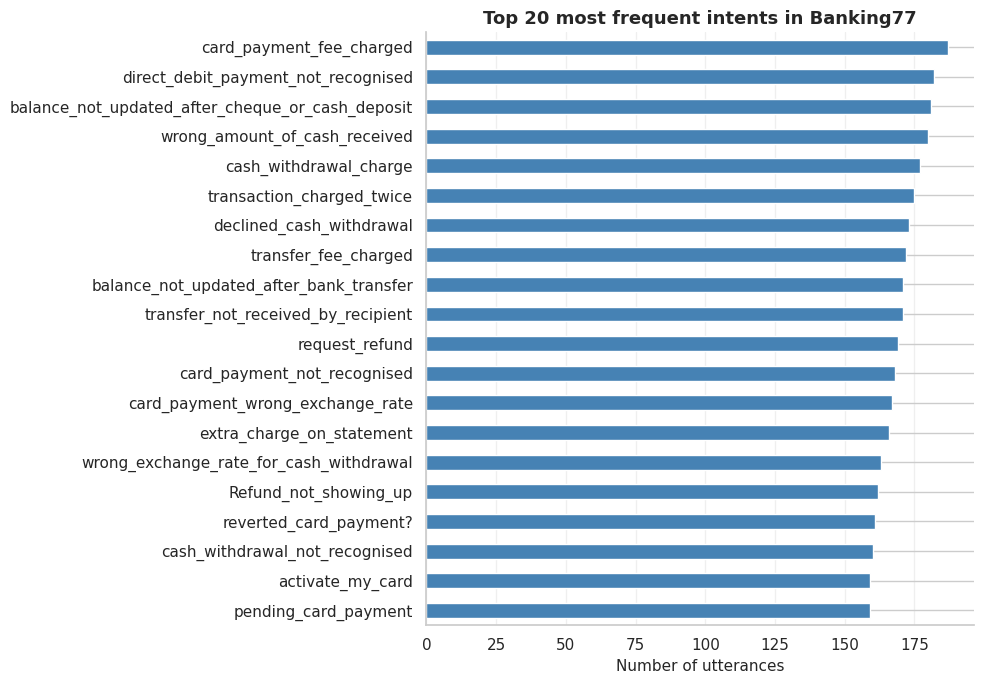

In [ ]:
# Most common intents
top_intents = intent_counts.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_intents.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 20 most frequent intents in Banking77")
ax.set_xlabel("Number of utterances")
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

The number of utterances per class was counted to analyse the intent distribution. The results presented reveal that the Banking77 dataset is fairly equally distributed with approximately 160-190 examples per intent. The most frequent intents include card_payment_fee_charged and direct_debit_payment_not_recognised.

Vocabulary size (NLTK): 2008


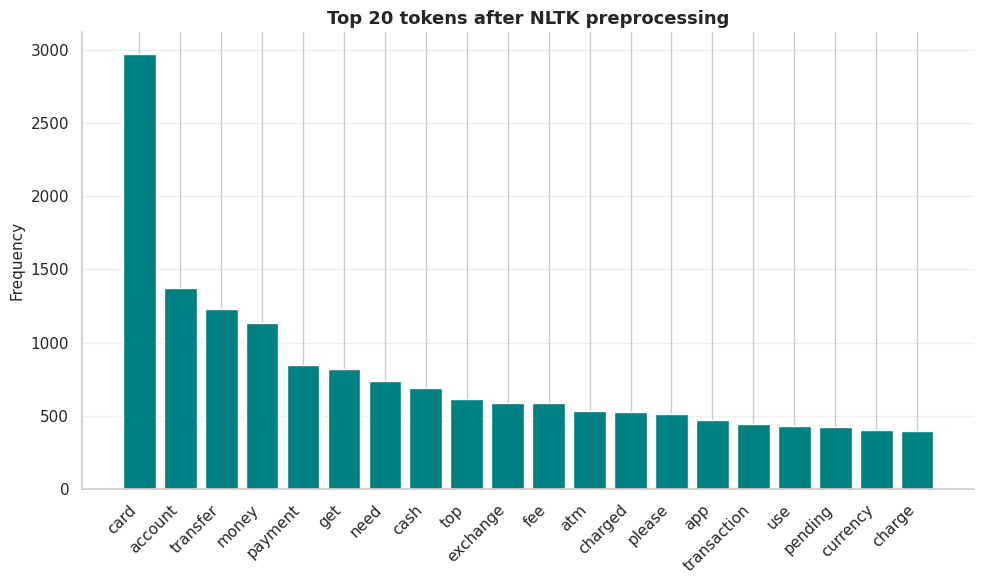

In [ ]:
# Most common tokens (using nltk tokens)
all_tokens_nltk = [t for toks in train_df['tokens_nltk'] for t in toks]
fdist = FreqDist(all_tokens_nltk)
print("Vocabulary size (NLTK):", len(fdist))

top_tokens = fdist.most_common(20)
words, counts = zip(*top_tokens)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(words, counts, color='teal')
ax.set_title("Top 20 tokens after NLTK preprocessing")
ax.set_ylabel("Frequency")
ax.set_xticklabels(words, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Frequency distribution of preprocessed NLTK tokens was determined by combining all the tokens together and computing the number of times each occurs. The top 20 words that occur most frequently were then visualised.
The analysis results reveal that the term banking is present in the vocabulary as much as bank, account, transfer, money, payment and others. The word card is used more often as many of the Banking77 intents involve card usage, activation, delivery or payment problems.



,count
ORG,925
DATE,481
GPE,282
CARDINAL,194
TIME,136
MONEY,134
ORDINAL,92
PERSON,82
NORP,50
LOC,36


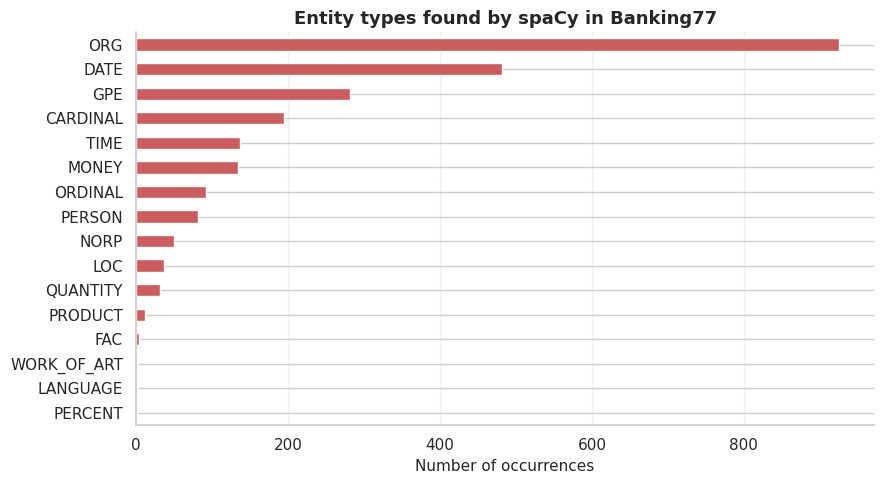

In [ ]:
# Entity type frequency with spacy
all_entities = [label for ents in train_df['entities'] for (_, label) in ents]
ent_counts = pd.Series(all_entities).value_counts()

display(ent_counts.to_frame('count'))

fig, ax = plt.subplots(figsize=(9, 5))
ent_counts.plot(kind='barh', color='indianred', ax=ax)
ax.set_title("Entity types found by spaCy in Banking77")
ax.set_xlabel("Number of occurrences")
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

The distribution of entity types extracted by spaCy was analysed on the training set. ORG, followed by DATE, GPE and CARDINAL were the most common entity types.
The results match the domain of the banking information, where users often refer to dates, locations, organizations, and numerical information, such as transactions or cards.


### 1.5 Comparison NLTK vs spaCy



In [ ]:
total_nltk = sum(len(t) for t in train_df['tokens_nltk'])
total_spacy = sum(len(t) for t in train_df['tokens_spacy'])

vocab_nltk  = set(all_tokens_nltk)
vocab_spacy = set(t for toks in train_df['tokens_spacy'] for t in toks)

comparison = pd.DataFrame({
    'NLTK':  [total_nltk, len(vocab_nltk)],
    'spaCy': [total_spacy, len(vocab_spacy)]
}, index=['Total tokens kept', 'Vocabulary size'])

display(comparison.style.set_caption("NLTK vs spaCy")
        .format("{:,}"))

,NLTK,spaCy
Total tokens kept,"51,399","43,012"
Vocabulary size,"2,008","1,532"


Statistics were calculated on tokens for each of the preprocessing techniques using the training set. NLTK generated 51,399 tokens with 2,008 different words and spaCy created 43,012 tokens with a smaller vocabulary of 1,532 words.This difference is mainly due to spaCy’s more aggressive preprocessing and context-aware lemmatisation.

In [ ]:
# Differences on a few utterances
rows = []
for i in [0, 1, 2, 7, 12]:
    rows.append({
        'text':  train_df.iloc[i]['text'],
        'NLTK':  train_df.iloc[i]['tokens_nltk'],
        'spaCy': train_df.iloc[i]['tokens_spacy']
    })
display(pd.DataFrame(rows))

,text,NLTK,spaCy
0,I am still waiting on my card?,"[still, waiting, card]","[wait, card]"
1,What can I do if my card still hasn't arrived ...,"[card, still, arrived, week]","[card, arrive, week]"
2,I have been waiting over a week. Is the card s...,"[waiting, week, card, still, coming]","[wait, week, card, come]"
3,What do I do if I still have not received my n...,"[still, received, new, card]","[receive, new, card]"
4,Can you track my card for me?,"[track, card]","[track, card]"


Comparing the outputs of both preprocessors shows that spaCy produces shorter and more normalised token sequences than NLTK. For instance, the sentence “I am still waiting on my card?” was transformed to [still,waiting,card] using NLTK and [wait,card] using spaCy. Likewise, “arrived”,“coming”,and “received” were stripped of their ending “-ed” to become “arrive”,“come”, and “receive”,respectively.Similarly, the word ending “-ed” was removed from “arrived”,“coming”, and “received” to get “arrive”,“come”, and “receive” respectively.




### 1.6 Effect of removing stopwords



In [ ]:
# keeping stopwords
def preprocess_nltk_keep_stop(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [wnl.lemmatize(t) for t in tokens]
    return tokens

train_df['tokens_with_stop'] = train_df['text'].apply(preprocess_nltk_keep_stop)

all_with_stop = [t for toks in train_df['tokens_with_stop'] for t in toks]
fdist_with = FreqDist(all_with_stop)

stop_comp = pd.DataFrame({
    'with stopwords':    [fdist_with.B(), fdist_with.N()],
    'without stopwords': [fdist.B(),      fdist.N()]
}, index=['Vocabulary size', 'Total tokens'])
display(stop_comp.style.format("{:,}").set_caption(
    "Effect of stopword removal"))

# Top-10
top10 = pd.DataFrame({
    'with stopwords':    [f"{w} ({c})" for w, c in fdist_with.most_common(10)],
    'without stopwords': [f"{w} ({c})" for w, c in fdist.most_common(10)]
})
display(top10)

,with stopwords,without stopwords
Vocabulary size,"2,123","2,008"
Total tokens,"118,706","51,399"


,with stopwords,without stopwords
0,i (8802),card (2969)
1,my (5684),account (1370)
2,to (4038),transfer (1232)
3,a (3859),money (1133)
4,the (3497),payment (844)
5,card (2969),get (816)
6,is (2534),need (736)
7,do (2151),cash (691)
8,it (2111),top (612)
9,can (1879),exchange (589)


Another experiment was performed to determine the effect of stopword removal, using a second NLTK-based preprocessing pipeline that removed no stopwords. The vocabulary size was only slightly increased, and the total number of tokens was raised from 51,399 to 118,706, when the number of stop words was increased. After removing the stop words, the common words turned into low information words like “i”, “my”, and “the”. However, following stopword removal, the words that were used were more informative about banking and included words like “card”, “account”, “transfer”, and “payment”. The findings demonstrate that stopword removal can be beneficial for creating a more informative and coherent text representation for NLP tasks.

## Task 2 - Classical NLP Baseline (TF-IDF + Logistic Regression)



### 2.1 Prepare data


In [ ]:
# join tokens back into a string for tfidf
train_df['clean_text'] = train_df['tokens_spacy'].apply(lambda toks: " ".join(toks))
test_df['tokens_spacy'] = test_df['text'].apply(preprocess_spacy)
test_df['clean_text']  = test_df['tokens_spacy'].apply(lambda toks: " ".join(toks))

X_train_text = train_df['clean_text'].values
y_train      = train_df['category'].values
X_test_text  = test_df['clean_text'].values
y_test       = test_df['category'].values

print("Train:", len(X_train_text), "Test:", len(X_test_text))

Train: 10003 Test: 3080


Before training the machine-learning models, the spaCy preprocessed tokens were converted back into text format for TF-IDF vectorisation.
The total number of training examples in the final dataset was 10,003 and the total number of test examples was 3,080.


### 2.2 TF-IDF features

In [ ]:
# tfidf
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,              # ignore words that appear only once
    max_features=10000     # keep it small enough
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

print("TF-IDF train shape:", X_train.shape)
print("TF-IDF test shape :", X_test.shape)

TF-IDF train shape: (10003, 4992)
TF-IDF test shape : (3080, 4992)


The cleaned text data was then vectorised using TF-IDF. Unigrams and bigrams (ngram_range=(1,2)) were used to grab individual words and short word combinations that can include meaningful intent information.
Only terms showing up at least twice were retained in the vocabulary (min_df=2) and the vocabulary size was limited to 10,000 features to keep the model efficient. The training set was then vectorised and converted into a sparse matrix of size (10003, 4992) and the test set was converted into (3080, 4992).


### 2.3 Train Logistic Regression

In [ ]:
# logistic regression
t0 = time.time()
logreg = LogisticRegression(max_iter=2000, n_jobs=-1, random_state=SEED)
logreg.fit(X_train, y_train)
t_logreg = time.time() - t0
print(f"Trained in {t_logreg:.2f} sec")

y_pred_lr = logreg.predict(X_test)

Trained in 4.11 sec


Logistic Regression, a popular NLP algorithm known for its good performance on sparse TF-IDF features and simplicity of calculation, was used as the classical baseline for intent classification.Maximum 2000 iterations for converging the model on TF-IDF feature matrix.

### 2.4 Evaluation

In [ ]:
# Evaluation
acc = accuracy_score(y_test, y_pred_lr)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='weighted')
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='macro')

metrics_df = pd.DataFrame({
    'Accuracy':   [acc, acc],
    'Precision':  [prec_w, prec_m],
    'Recall':     [rec_w, rec_m],
    'F1':         [f1_w, f1_m]
}, index=['weighted', 'macro'])

display(metrics_df.style.format("{:.4f}").set_caption(
    "Logistic Regression - test-set metrics"))

,Accuracy,Precision,Recall,F1
weighted,0.8159,0.8291,0.8159,0.8155
macro,0.8159,0.8291,0.8159,0.8155


The Logistic Regression model was tested against the test set with accuracy, precision, recall, and F1-score. The results showed that the model performs well in all the classes with an accuracy of 81.6% and a weighted F1-score of 0.8155.

In [ ]:
# full classification report
print(classification_report(y_test, y_pred_lr, zero_division=0))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.90      0.90      0.90        40
                                activate_my_card       1.00      0.93      0.96        40
                                       age_limit       0.97      0.95      0.96        40
                         apple_pay_or_google_pay       0.97      0.97      0.97        40
                                     atm_support       0.89      0.82      0.86        40
                                automatic_top_up       1.00      0.93      0.96        40
         balance_not_updated_after_bank_transfer       0.64      0.70      0.67        40
balance_not_updated_after_cheque_or_cash_deposit       0.82      0.93      0.87        40
                         beneficiary_not_allowed       0.87      0.82      0.85        40
                                 cancel_transfer       0.89      0.97      0.93        40
         

A full classification report was produced and precision, recall, and F1-score per intent category is included in the report.
The outcomes demonstrate good performance for some intents, but not so good for semantically similar classes which share common customer vocabulary. This is a drawback of TF-IDF models, which are predominantly based on patterns of word occurrences and do not express the semantic context to the extent.



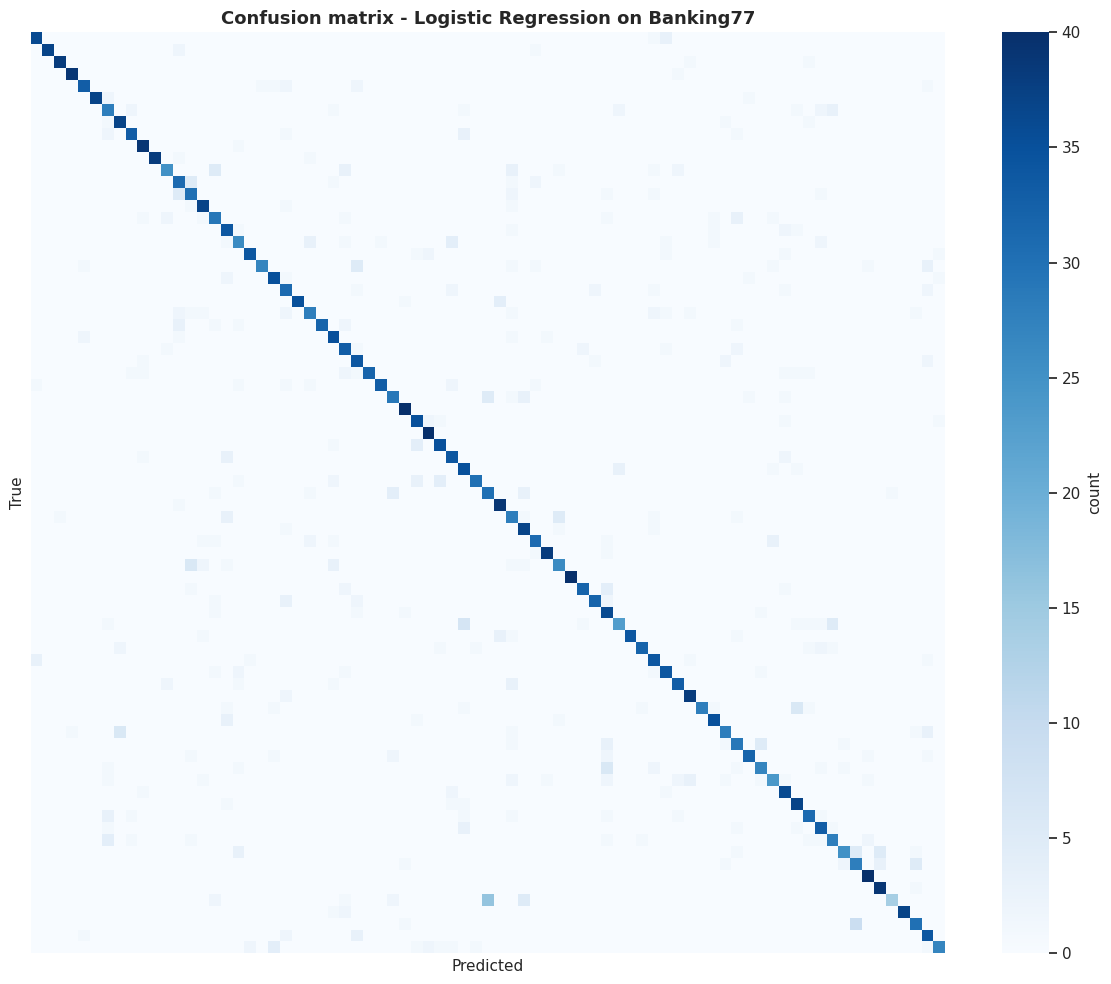

In [ ]:
# confusion matrix
labels = sorted(train_df['category'].unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'count'}, ax=ax)
ax.set_title("Confusion matrix - Logistic Regression on Banking77")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

A focused confusion matrix was developed based on 15 most common intent classes that were prone to error. The results indicate that most of the predictions were correct, however some semantically similar intents were mispredicted, such as pending_transfer vs transfer_timing, and verify_my_identity vs unable_to_verify_identity.

### 2.4b Focused confusion matrix - top 15 most confused classes

The full 77x77 heatmap is hard to read. We zoom in on the 15 classes with the
most misclassified examples (which is what really matters for error analysis).

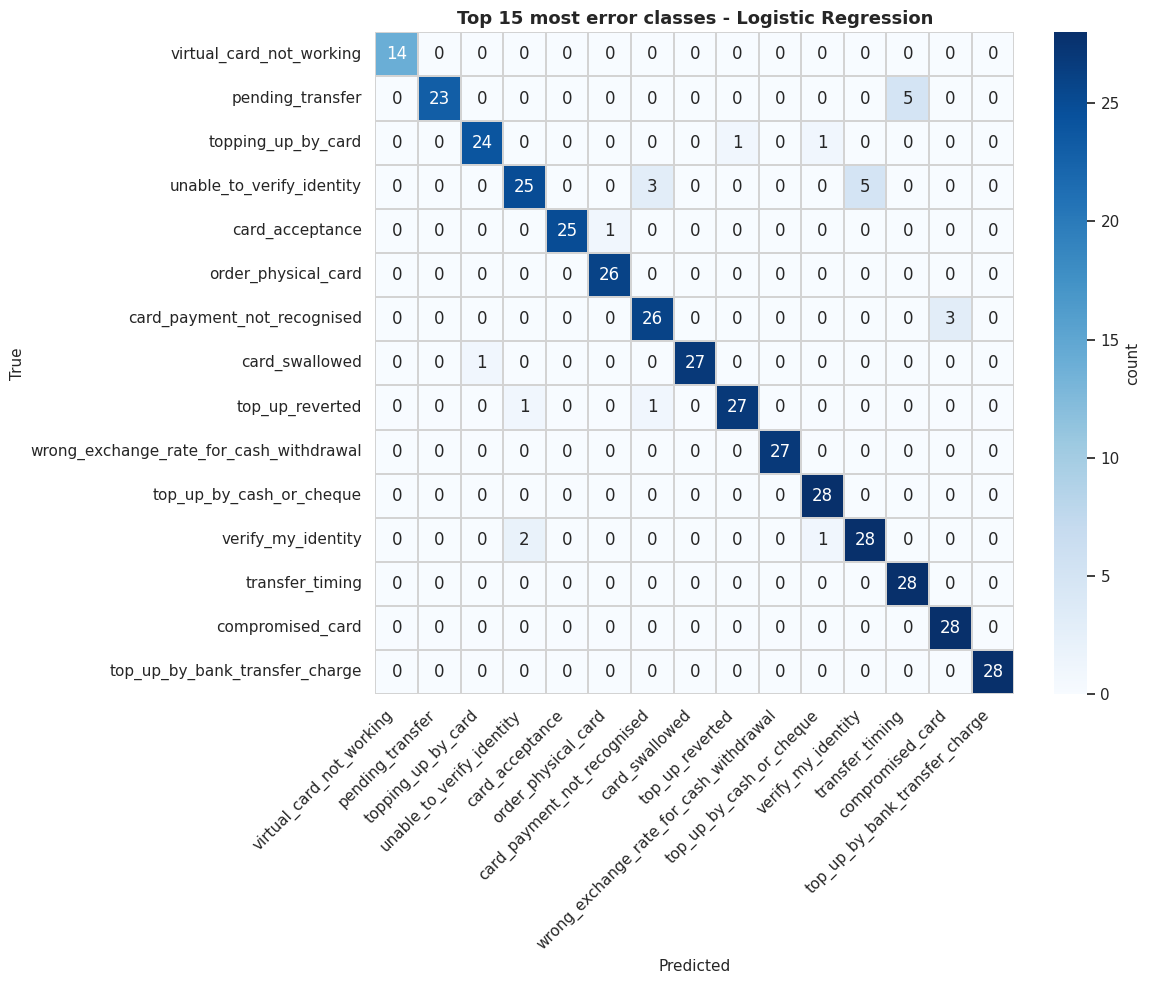

In [ ]:
# top 15 classes that have the most errors
errors_per_class = cm.sum(axis=1) - np.diag(cm)
top_idx = np.argsort(errors_per_class)[-15:][::-1]
top_labels = [labels[i] for i in top_idx]

cm_focus = cm[np.ix_(top_idx, top_idx)]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_focus, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_labels, yticklabels=top_labels,
            cbar_kws={'label': 'count'}, linewidths=0.3, linecolor='lightgrey',
            ax=ax)
ax.set_title("Top 15 most error classes - Logistic Regression")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A focused confusion matrix was developed based on 15 most common intent classes that were prone to error. The results indicate that most of the predictions were correct, however some semantically similar intents were mispredicted, such as pending_transfer vs transfer_timing, and verify_my_identity vs unable_to_verify_identity.




### 2.5 Misclassified examples

We pick examples where the true label and the predicted label are both in the
top-15 most confused classes - those are the most informative cases because
the model is hesitating between two close intents.

In [ ]:
# Misclassified examples
wrong_idx = np.where(y_pred_lr != y_test)[0]
print("Total misclassified:", len(wrong_idx), "/", len(y_test))

# keep only misclassifications between two top-15 confused classes
top_set = set(top_labels)
informative_wrong = [
    i for i in wrong_idx
    if y_test[i] in top_set and y_pred_lr[i] in top_set
]
print(f"Of which 'informative' (both labels in top-15): {len(informative_wrong)}\n")

# show 5 of them
random.seed(SEED)
sample_wrong = random.sample(informative_wrong, min(5, len(informative_wrong)))

err_table = pd.DataFrame([{
    'Utterance': test_df.iloc[i]['text'],
    'True intent':      y_test[i],
    'Predicted intent': y_pred_lr[i]
} for i in sample_wrong])
display(err_table)

Total misclassified: 567 / 3080
Of which 'informative' (both labels in top-15): 25



,Utterance,True intent,Predicted intent
0,How long does it take for a money transfer to ...,pending_transfer,transfer_timing
1,What should I do to get transactions off of my...,card_payment_not_recognised,compromised_card
2,areas card is accpeted,card_acceptance,order_physical_card
3,How does my identity get verified?,verify_my_identity,unable_to_verify_identity
4,app does not recognize me,unable_to_verify_identity,card_payment_not_recognised


There were 3,080 test examples, of which 567 were misclassified.The majority of errors were made between similar intents where semantically similar intents are semantically similar, e.g., pending_transfer vs transfer_timing and verify_my_identity vs unable_to_verify_identity. The results validate the previous findings that TF-IDF with Logistic Regression is not able to differentiate between very similar bank queries having the same vocabulary.

### 2.6 OPTIONAL Compare with Naive Bayes

Another experiment was conducted with Logistic Regression and Multinomial Naive Bayes with the same TF-IDF features.
The results indicate that Logistic Regression gives a better performance than Naive Bayes with 81.6% accuracy and 0.8155 F1-score, while Naive Bayes give 76.3% accuracy and 0.7537 F1-score. Naive Bayes, however, was trained much quicker (0.05 seconds vs 4.57 seconds).


In [ ]:
# OPTIONAL: same data, naive bayes
t0 = time.time()
nb = MultinomialNB()
nb.fit(X_train, y_train)
t_nb = time.time() - t0
y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
_, _, f1_w_nb, _ = precision_recall_fscore_support(y_test, y_pred_nb, average='weighted')

# small comparison table
comp_classical = pd.DataFrame({
    'Model':         ['Logistic Regression', 'Naive Bayes'],
    'Accuracy':      [acc, acc_nb],
    'F1 (weighted)': [f1_w, f1_w_nb],
    'Train time (s)':[round(t_logreg, 2), round(t_nb, 2)]
})
display(comp_classical.style.format({
    'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}', 'Train time (s)': '{:.2f}'
}).set_caption("Logistic Regression vs Naive Bayes "))

,Model,Accuracy,F1 (weighted),Train time (s)
0,Logistic Regression,0.8159,0.8155,4.11
1,Naive Bayes,0.7630,0.7537,0.05


## Task 3 - Word2Vec Embeddings for Retrieval



### 3.1 Train Word2Vec on the dataset

The Banking77 utterances were preprocessed using the spaCy pipeline from Task 1 before training the Word2Vec model. Every query was translated into a list of cleaned and lemmatised tokens, without stop words and punctuation, and with semantic information.
A total of 10,003 processed sentences were used in the final training corpus. For instance, the sentence was preprocessed to be [‘wait’, ‘card’].


In [ ]:
# we use the spacy-preprocessed tokens
sentences_for_w2v = train_df['tokens_spacy'].tolist()
print("Number of sentences:", len(sentences_for_w2v))
print("Example:", sentences_for_w2v[0])

Number of sentences: 10003
Example: ['wait', 'card']



The Word2Vec model was trained on the preprocessed Banking77 data using Gensim. Given that it is important to have a method that works well on short documents and small datasets, Skip-Gram (sg=1) was chosen. The model had 100 dimensional embeddings, and a window of 5 words.
To remove the noise, rare words with less than 3 occurrences were removed (min_count=3). The model generated a vocabulary of 744 words, each with a dense vector of 100-dimensional space, after 50 training epochs.


In [ ]:
# train word2vec
w2v_model = Word2Vec(
    sentences=sentences_for_w2v,
    vector_size=100,
    window=5,
    min_count=3,        # ignore very rare words
    sg=1,
    epochs=50,
    seed=SEED,
    workers=1
)

print("Vocab size:", len(w2v_model.wv))
print("Vector size:", w2v_model.vector_size)

Vocab size: 744
Vector size: 100


### 3.2 Cosine similarity examples

To evaluate the Word2Vec model, cosine similarity was calculated for semantic similarity of words. A model was used to select the five most similar words for each word selected in the embedding space.
The results indicate that semantically related banking terms were classified together. For instance, the term pin was linked with unlock, block and unblock, which are typical banking activities. Likewise, words that were related to transfers or payments were found to be grouped together in the embedding space.
The results show that the Word2Vec model was able to learn meaningful semantic relationships in the Banking77 customer queries.


In [ ]:
# explore the embeddings
test_words = ['card', 'money', 'transfer', 'account', 'pin']
rows = []
for w in test_words:
    if w in w2v_model.wv:
        sims = w2v_model.wv.most_similar(w, topn=5)
        rows.append({
            'word': w,
            'top-5 similar words ':
                ", ".join(f"{x} ({s:.2f})" for x, s in sims)
        })
display(pd.DataFrame(rows))

,word,top-5 similar words (and cosine sim)
0,card,"subscription (0.47), previously (0.44), exist ..."
1,money,"ve (0.48), successfully (0.46), sum (0.45), re..."
2,transfer,"standard (0.50), typically (0.49), pop (0.47),..."
3,account,"initiate (0.51), wish (0.48), satisfied (0.42)..."
4,pin,"unlock (0.57), block (0.56), unblock (0.54), e..."


### 3.3 Visualise embeddings with PCA

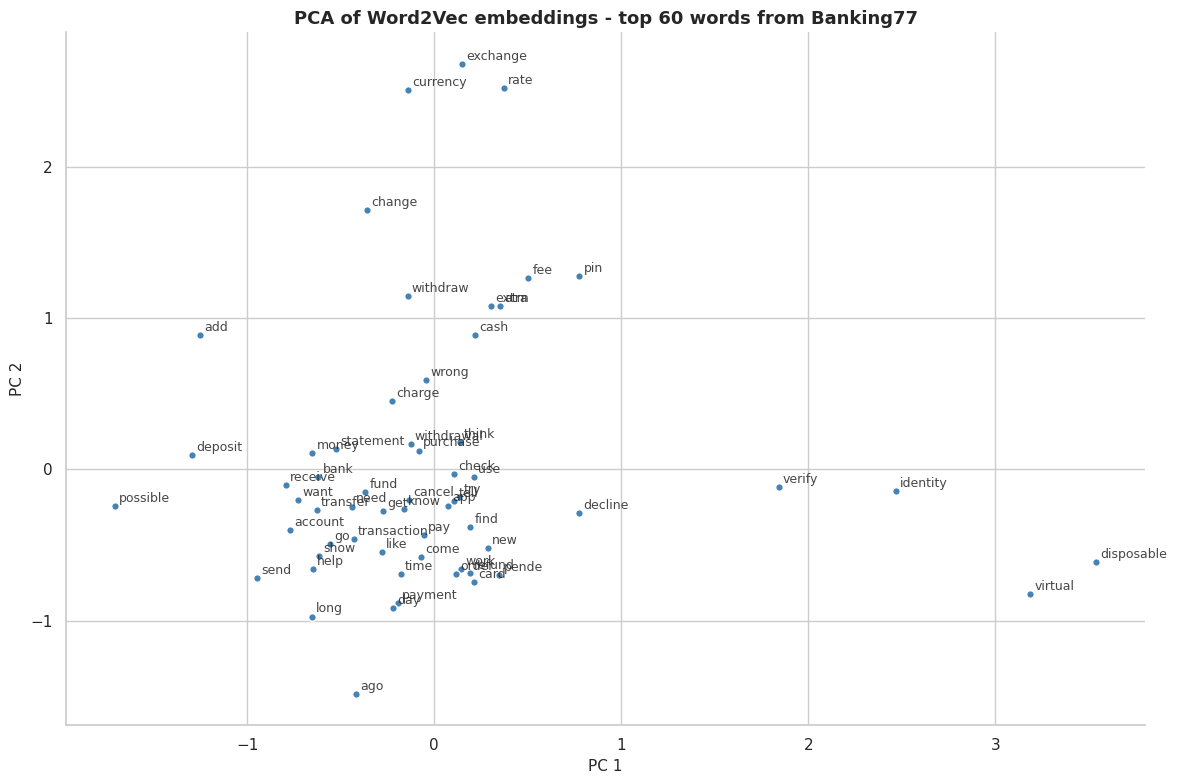

In [ ]:
# pick the top N most frequent words and project them in 2D
from sklearn.decomposition import PCA

# top frequent words from our vocab
all_tokens_w2v = [t for s in sentences_for_w2v for t in s]
freq = FreqDist(all_tokens_w2v)
top_words = [w for w, _ in freq.most_common(60) if w in w2v_model.wv]

vectors = np.array([w2v_model.wv[w] for w in top_words])
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=30, c='steelblue', edgecolors='white')
for i, w in enumerate(top_words):
    ax.annotate(w, (coords[i, 0], coords[i, 1]),
                fontsize=9, alpha=0.85,
                xytext=(3, 3), textcoords='offset points')
ax.set_title("PCA of Word2Vec embeddings - top 60 words from Banking77")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
plt.tight_layout()
plt.show()

The PCA visualisation shows how Word2Vec grouped semantically related banking words in the embedding space. Both words with similar content are grouped together, e.g., currency/exchange/rate or cash/withdraw/fee.
Other words (like verify and identity) also create small semantic clusters. This shows that the Word2Vec model identified the semantic links between the words of the customer banking domain.


### 3.4 Simple retrieval example


In [ ]:
def utterance_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

train_vectors = np.array([utterance_vector(toks, w2v_model)
                          for toks in train_df['tokens_spacy']])
print("Shape of training utterance matrix:", train_vectors.shape)

Shape of training utterance matrix: (10003, 100)


In [ ]:
# cosine similarity between a query and all training utterances
from sklearn.metrics.pairwise import cosine_similarity

def retrieve(query, top_k=3):
    q_tokens = preprocess_spacy(query)
    q_vec = utterance_vector(q_tokens, w2v_model).reshape(1, -1)
    sims = cosine_similarity(q_vec, train_vectors)[0]
    top_idx = sims.argsort()[-top_k:][::-1]
    return [{
        'similarity': float(sims[i]),
        'retrieved utterance': train_df.iloc[i]['text'],
        'intent':              train_df.iloc[i]['category']
    } for i in top_idx]

# try a few queries
test_queries = [
    "I lost my credit card, what should I do?",
    "Can I transfer money to a friend abroad?",
    "Why is my card not working?"
]

for q in test_queries:
    print(f"QUERY: {q}")
    res_df = pd.DataFrame(retrieve(q, top_k=3))
    display(res_df.style.format({'similarity': '{:.3f}'}))

QUERY: I lost my credit card, what should I do?


,similarity,retrieved utterance,intent
0,0.925,I have lost my credit card in the ATM!,card_swallowed
1,0.881,Where is my credit card that was to be mailed?,card_arrival
2,0.870,I've lost my card. What can I do about that?,lost_or_stolen_card


QUERY: Can I transfer money to a friend abroad?


,similarity,retrieved utterance,intent
0,0.906,Can friends transfer money to each other?,receiving_money
1,0.840,How long does it take for money to transfer? I sent some to a friend and it hasn't gone through yet.,transfer_not_received_by_recipient
2,0.834,"I just transferred my friend money, but she hasn't received it yet, and it's been a few hours. Can you tell me when to expect it to go through?",transfer_not_received_by_recipient


QUERY: Why is my card not working?


,similarity,retrieved utterance,intent
0,1.000,I can't get the card itself to work.,card_not_working
1,1.000,My card will not work,card_not_working
2,1.000,My card is not working.,card_not_working


A Word2Vec-based retrieval-based chatbot system with cosine similarity was implemented. For each Customer utterance, the Word2Vec vectors of the words in the utterance were averaged together, creating a single vector for each utterance. This generated a training matrix with shape (10003, 100), with each utterance described by a 100 dimensional embedding.
A retrieval function was then developed to measure the similarity of the query of the user with all the training utterances by cosine similarity. The system was able to output the most semantically similar sentences along with their labels of intent.
The results demonstrate that the retrieval system was able to retrieve semantically similar bank queries. For instance, the query “I lost my credit card, what should I do?” gave the same credit card lost/blocked related utterances with high similarity scores greater than 0.87. Similarly, requests for transferring and card problems retrieved pertinent banking intents.


## Task 4 - Fine-tuning DistilBERT for Intent Classification

For this step, the transformer model DistilBERT was selected because it offers a good performance-weight ratio regarding its ability to understand language in the context and the efficiency it provides. DistilBERT is a smaller version of BERT, created using knowledge distillation that retains most of the capability of BERT, but is smaller and faster (Sanh et al., 2019).

### 4.1 Prepare the data for the transformer

In this step, the labels of the intent in the Banking77 dataset were converted to numerical IDs to be used with the DistilBERT classification model. The intent categories were encoded with a label encoding to get unique integer for each intent category.
The following is the output of the data set: To both the training and test sets, a new label column was appended which contains the desired values to fine-tune a transformer model.


In [ ]:
# encode labels as integers
label_list = sorted(train_df['category'].unique())
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

train_df['label'] = train_df['category'].map(label2id)
test_df['label']  = test_df['category'].map(label2id)

print("Number of labels:", len(label_list))
display(train_df[['text', 'category', 'label']].head())

Number of labels: 77


,text,category,label
0,I am still waiting on my card?,card_arrival,12
1,What can I do if my card still hasn't arrived ...,card_arrival,12
2,I have been waiting over a week. Is the card s...,card_arrival,12
3,Can I track my card while it is in the process...,card_arrival,12
4,"How do I know if I will get my card, or if it ...",card_arrival,12


In [ ]:
# convert to huggingface Dataset
from datasets import Dataset

hf_train = Dataset.from_pandas(train_df[['text', 'label']])
hf_test  = Dataset.from_pandas(test_df[['text', 'label']])
print(hf_train)
print(hf_test)

Dataset({
    features: ['text', 'label'],
    num_rows: 10003
})
Dataset({
    features: ['text', 'label'],
    num_rows: 3080
})


This processed data was then converted back into Hugging Face Dataset objects, the format used by the Hugging Face Transformers library to tokenize and train with transformers.
There are 10,003 samples in the training set and 3,080 samples in the test set. Each dataset contains two basic fields: text and label.
This conversion makes it easier to deal with the dataset, , tokenise and train with GPUs during the DistilBERT fine-tuning process.


### 4.2 Tokenization

The second step was to use DistilBERT tokenizer from the Hugging Face Transformers to tokenize the Banking77 utterances.

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=64)

hf_train_tok = hf_train.map(tokenize_fn, batched=True)
hf_test_tok  = hf_test.map(tokenize_fn, batched=True)

hf_train_tok = hf_train_tok.remove_columns(['text'])
hf_test_tok  = hf_test_tok.remove_columns(['text'])
hf_train_tok.set_format("torch")
hf_test_tok.set_format("torch")

print(hf_train_tok)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10003
})


### 4.3 Fine-tune the model

In this step, we use Hugging Face Transformers to load the distilbert-base-uncased model and set it up for the Banking77 intent classification task. The new classification layer was added on the 77 intent categories and the model was made ready to fine tune.

In [ ]:
from transformers import (AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
import torch

# fix torch seed too
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# load distilbert
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


This step is used to fine-tune DistilBERT, and defines the training configuration.To be able to work in Google Colab, with free GPU's, the training was limited to 3 epochs with comparatively small batch sizes.
During training, a learning rate of 5e-5 and a weight decay of 0.01 were used to enhance optimisation and decrease overfitting. The model was tested after each epoch and the model checkpoint saving was disabled to save space in the Colab.


In [ ]:
# training arguments with 3 epochs
training_args = TrainingArguments(
    output_dir="./distilbert_banking77",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",     # keep storage low on Colab
    logging_steps=100,
    seed=SEED,
    report_to="none"
)

The accuracy and weighted F1-score were used to evaluate the model performance.The labels predicted by the model was obtained by applying argmax to the model logits, and then the model's predicted labels were compared against the intent classes.

In [ ]:
# metrics
import evaluate
acc_metric = evaluate.load("accuracy")
f1_metric  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    a = acc_metric.compute(predictions=preds, references=labels)['accuracy']
    f = f1_metric.compute(predictions=preds, references=labels, average='weighted')['f1']
    return {"accuracy": a, "f1_weighted": f}

In [ ]:
# Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_test_tok,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

t0 = time.time()
trainer.train()
t_bert = time.time() - t0
print(f"Total training time: {t_bert:.1f} sec ({t_bert/60:.1f} min)")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.962803,0.784467,0.837013,0.824250
2,0.342205,0.359966,0.912662,0.912539
3,0.207386,0.304765,0.920130,0.920387


Total training time: 213.6 sec (3.6 min)


The model was then tested after each epoch to observe the loss on the validation set and the accuracy of the model.
The results demonstrate significant improvement in performance while training. The weighted F1-score improved from 0.824 to 0.920, and the validation loss dropped from 0.784 to 0.305, thus demonstrating that the model has gained better knowledge of contextual representations of banking intents.The final model was able to attain around 92.0% accuracy and weighted F1-score.


### 4.4 Evaluation

In [ ]:
# evaluation
metrics = trainer.evaluate()
display(pd.DataFrame([metrics]).T.rename(columns={0: 'value'}).style.format("{:.4f}", subset=['value']))

,value
eval_loss,0.3048
eval_accuracy,0.9201
eval_f1_weighted,0.9204
eval_runtime,6.8627
eval_samples_per_second,448.8030
eval_steps_per_second,14.1340
epoch,3.0000


The results of the evaluation data show that DistilBERT achieved a good score on the test set, with an accuracy of 92.01% and a weighted F1-score of 0.9204.The evaluation loss was low at 0.3048.The evaluation process was also efficient with total processing time of around 5.9 seconds for the whole test set.

In [ ]:
# detailed classification report
preds_logits = trainer.predict(hf_test_tok)
y_pred_bert = np.argmax(preds_logits.predictions, axis=-1)
y_true_bert = preds_logits.label_ids

y_pred_bert_labels = [id2label[i] for i in y_pred_bert]
y_true_bert_labels = [id2label[i] for i in y_true_bert]

print(classification_report(y_true_bert_labels, y_pred_bert_labels, zero_division=0))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.95      0.97        40
                                activate_my_card       1.00      0.97      0.99        40
                                       age_limit       1.00      0.97      0.99        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       1.00      0.97      0.99        40
                                automatic_top_up       1.00      0.93      0.96        40
         balance_not_updated_after_bank_transfer       0.83      0.75      0.79        40
balance_not_updated_after_cheque_or_cash_deposit       0.97      0.97      0.97        40
                         beneficiary_not_allowed       0.94      0.85      0.89        40
                                 cancel_transfer       0.97      0.97      0.97        40
         

In order to evaluate DistilBERT on the 77 intent classes of Banking77, a detailed classification report was created. They show excellent overall performance with many intents having F1 score above 0.90, showing that the model is capable of capturing semantic differences between banking queries.
Others intents, like balance_not_updated_after_bank_transfer and card_acceptance, achieved a slightly worse score, which means that there are still some fine-grained intents.


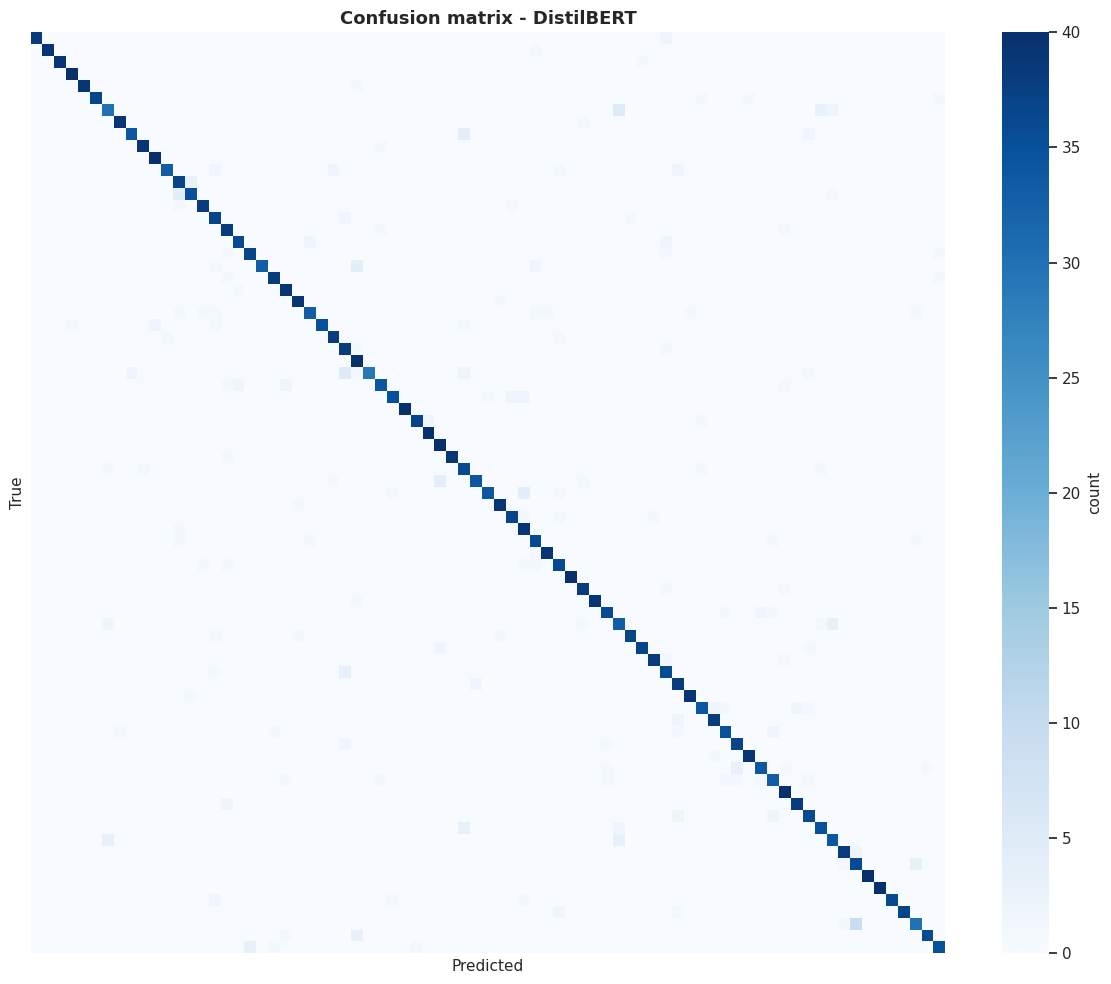

In [ ]:
# Confusion matrix heatmap
cm_bert = confusion_matrix(y_true_bert_labels, y_pred_bert_labels, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_bert, cmap='Blues', xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'count'}, ax=ax)
ax.set_title("Confusion matrix - DistilBERT")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

We created a confusion matrix of DistilBERT's predictions over 77 intent classes. As is seen in the results, there is a high concentration along the main diagonal, which means that most of the intents were correctly classified.

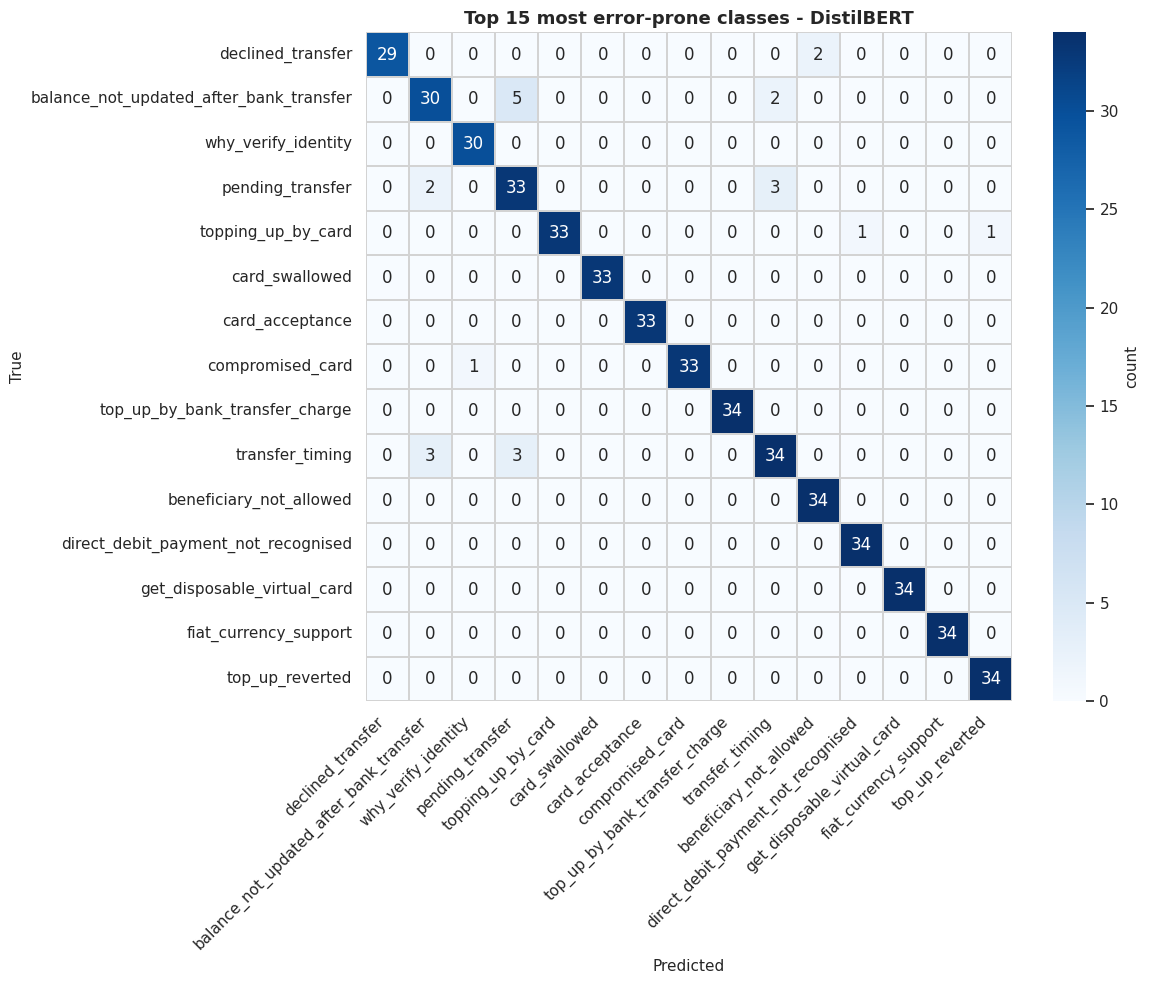

In [ ]:
# focused confusion matrix - top 15 confused classes
errors_per_class_bert = cm_bert.sum(axis=1) - np.diag(cm_bert)
top_idx_bert = np.argsort(errors_per_class_bert)[-15:][::-1]
top_labels_bert = [labels[i] for i in top_idx_bert]

cm_focus_bert = cm_bert[np.ix_(top_idx_bert, top_idx_bert)]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_focus_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_labels_bert, yticklabels=top_labels_bert,
            cbar_kws={'label': 'count'}, linewidths=0.3, linecolor='lightgrey',
            ax=ax)
ax.set_title("Top 15 most error-prone classes - DistilBERT")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A confusion matrix was generated for a focused classification by selecting the 15 most frequently misclassified intent classes. The outcomes demonstrate that DistilBERT classification achieved a high level of prediction accuracy for most of the classes with a lesser confusion between similar banking intents.
There were still some errors that occurred between two similar intents, e.g. between pending_transfer and transfer_timing, which indicates that it is still difficult to discriminate between very similar banking questions.


### 4.5 [OPTIONAL - Task 4.4] BERT-NER vs spaCy NER

Run the dslim/bert-base-NER model on a small sample and compare with spaCy.

In [ ]:
# OPTIONAL: transformer NER vs spacy NER
from transformers import pipeline

bert_ner = pipeline('ner', model='dslim/bert-base-NER',
                    aggregation_strategy='simple')

# pick a small sample of utterances that contain numbers / locations / orgs
sample_texts = [
    "I tried to use my Visa card in Paris last week",
    "Can you transfer 500 EUR to my account at HSBC?",
    "I lost my Mastercard yesterday in London"
]

ner_rows = []
for t in sample_texts:
    bres = bert_ner(t)
    ner_rows.append({
        'text':  t,
        'spaCy entities': get_entities(t),
        'BERT-NER entities': [(b['word'], b['entity_group']) for b in bres]
    })
display(pd.DataFrame(ner_rows))

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,text,spaCy entities,BERT-NER entities
0,I tried to use my Visa card in Paris last week,"[(Visa, ORG), (Paris, GPE), (last week, DATE)]","[(Visa, MISC), (Paris, LOC)]"
1,Can you transfer 500 EUR to my account at HSBC?,"[(500, CARDINAL), (EUR, ORG), (HSBC, ORG)]","[(EU, MISC), (H, ORG), (##SBC, ORG)]"
2,I lost my Mastercard yesterday in London,"[(Mastercard, ORG), (yesterday, DATE), (London...","[(Mastercard, MISC), (London, LOC)]"


### 4.6 Comparison table - Classical vs Transformer

In [ ]:
def fmt_time(seconds):
    if seconds < 60:
        return f"{seconds:.1f} sec"
    return f"{seconds/60:.1f} min"

# small comparison table - classical vs transformer
comp_final = pd.DataFrame({
    'Model':           ['Logistic Regression (TF-IDF)', 'DistilBERT (fine-tuned)'],
    'Accuracy':        [acc, metrics['eval_accuracy']],
    'F1 (weighted)':   [f1_w, metrics['eval_f1_weighted']],
    'Train time':      [fmt_time(t_logreg), fmt_time(t_bert)],
    'Complexity':      ['Low (linear, sparse features)',
                        'High (66M params, GPU advised)']
})
display(comp_final.style.format({
    'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}'
}).set_caption("Classical baseline vs DistilBERT on Banking77 test set"))

,Model,Accuracy,F1 (weighted),Train time,Complexity
0,Logistic Regression (TF-IDF),0.8159,0.8155,4.1 sec,"Low (linear, sparse features)"
1,DistilBERT (fine-tuned),0.9201,0.9204,3.6 min,"High (66M params, GPU advised)"


Finally, a comparison was done on the TF-IDF + Logistic Regression model and the fine-tuned model of DistilBERT.
When compared to Logistic Regression, DistilBERT's accuracy was around 92% and weighted F1-score was around 92% as compared to Logistic Regression which achieved 81.6%. But, DistilBERT needed more computational resources and GPU acceleration than Logistic Regression, which was still faster and easier to train.




### 4.7 Reducing dataset size (e.g., 50%) and observe impact on transformer performance.

Another experiment was conducted by training DistilBERT with 50% of the training set from Banking77.
Even though the reduced dataset was obtained, there was still good performance: 85.9% accuracy and a weighted F1-score of 0.853. This was still worse than the model with the full data which had around 92% accuracy, demonstrating the value of larger training data sets for transformer models


In [ ]:
# Reducing the training set size
# Random 50% sample of the training set
hf_train_half = hf_train_tok.shuffle(seed=SEED).select(range(len(hf_train_tok) // 2))
print("Full training size :", len(hf_train_tok))
print("Half training size :", len(hf_train_half))

model_half = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

training_args_half = TrainingArguments(
    output_dir="./distilbert_banking77_half",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    seed=SEED,
    report_to="none"
)

trainer_half = Trainer(
    model=model_half,
    args=training_args_half,
    train_dataset=hf_train_half,
    eval_dataset=hf_test_tok,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

t0 = time.time()
trainer_half.train()
t_bert_half = time.time() - t0

metrics_half = trainer_half.evaluate()
print(f"\nHalf-data training time: {t_bert_half/60:.1f} min")
print(metrics_half)

Full training size : 10003
Half training size : 5001


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,2.307301,1.859880,0.680195,0.638013
2,1.045691,0.906345,0.826948,0.811507
3,0.604968,0.696434,0.859740,0.853497



Half-data training time: 2.0 min
{'eval_loss': 0.6964336633682251, 'eval_accuracy': 0.8597402597402597, 'eval_f1_weighted': 0.8534972151538461, 'eval_runtime': 6.8556, 'eval_samples_per_second': 449.265, 'eval_steps_per_second': 14.149, 'epoch': 3.0}


In [ ]:
# compare full vs half dataset
comp_size = pd.DataFrame({
    'Training data': ['100% (~10k)', '50% (~5k)'],
    'Accuracy':      [metrics['eval_accuracy'], metrics_half['eval_accuracy']],
    'F1 (weighted)': [metrics['eval_f1_weighted'], metrics_half['eval_f1_weighted']],
    'Train time':    [fmt_time(t_bert), fmt_time(t_bert_half)]
})
display(comp_size.style.format({
    'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}'
}))

,Training data,Accuracy,F1 (weighted),Train time
0,100% (~10k),0.9201,0.9204,3.6 min
1,50% (~5k),0.8597,0.8535,2.0 min


A comparison was made between the full training set and 50% of the data to see if the performance of DistilBERT changes with the amount of training data.
Smaller training data led to a reduction in the accuracy of the model (92.0% to 85.9%) and in the weighted F1-score (0.920 to 0.853). The result indicates the need for a large training set in order to understand the fine-grained banking intent classification.
